# import các thư viện cần thiết


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectFromModel
from scipy.spatial import ConvexHull
from scipy.stats import entropy
import networkx as nx 
import warnings


# tắt cảnh báo he

In [38]:
warnings.filterwarnings("ignore")

In [39]:
NUM_ROIS = 30

# 1. Đọc dữ liệu
file_path = 'D:\\Code_File\\DAV\\final project\\original_file.csv'
df = pd.read_csv(file_path)

In [40]:
# TÍNH ĐẶC TRƯNG ĐỒ THỊ (GRAPH FEATURES)
def get_graph_features(rois_seq):
    if len(rois_seq) < 2: return [0, 0, 0, 0]
    G = nx.DiGraph()
    edges = [(rois_seq[i], rois_seq[i+1]) for i in range(len(rois_seq)-1)]
    G.add_edges_from(edges)
    density = nx.density(G)
    # Độ co cụm (Nhìn tập trung hay dàn trải)
    try:
        avg_clustering = nx.average_clustering(G.to_undirected())
    except:
        avg_clustering = 0
    #Số vùng bị cô lập
    num_components = nx.number_strongly_connected_components(G)
    # Xu hướng nối các điểm giống nhau
    try:
        assortativity = nx.degree_assortativity_coefficient(G)
        if np.isnan(assortativity): assortativity = 0
    except:
        assortativity = 0
        
    return [density, avg_clustering, num_components, assortativity]

In [41]:
# hàm tổng hợp
def get_scanpath_and_features(user_data, cluster_centers):
    if len(user_data) < 3: return None, None, None
    rois = cluster_centers.predict(user_data[['FIX_X', 'FIX_Y']])
    # chr(65)='A', chr(97)='a'... để an toàn ta dùng số luôn cho vectorizer
    path_str = " ".join([str(r) for r in rois])
    points = user_data[['FIX_X', 'FIX_Y']].values
    diffs = np.diff(points, axis=0)
    path_len = np.sum(np.sqrt(np.sum(diffs**2, axis=1)))
    try:
        hull = ConvexHull(points)
        hull_area = hull.volume
    except:
        hull_area = 0
    val_counts = pd.Series(rois).value_counts(normalize=True)
    full_counts = np.zeros(NUM_ROIS)
    for r, v in val_counts.items():
        full_counts[r] = v
    ent = entropy(full_counts + 1e-10)
    
    dur_mean = user_data['FIX_DURATION'].mean()
    graph_feats = get_graph_features(rois)
    return path_str, [path_len, hull_area, ent, dur_mean], graph_feats

In [42]:

# vòng lặp chính
print(f"Đang xử lý với K={NUM_ROIS} và trích xuất Graph Features...")
patient_docs = {} 
patient_phys = {}
patient_graph = {}
unique_images = df['image_id'].unique()
for img_id in unique_images:
    img_data = df[df['image_id'] == img_id].copy()
    if len(img_data) < 50: continue
    
    kmeans_roi = KMeans(n_clusters=NUM_ROIS, random_state=42, n_init=10)
    kmeans_roi.fit(img_data[['FIX_X', 'FIX_Y']])
    
    for pid, group in img_data.groupby('numeric_id'):
        path_str, phys, graph = get_scanpath_and_features(group, kmeans_roi)
        
        if path_str:
            if pid not in patient_docs: 
                patient_docs[pid] = []
                patient_phys[pid] = []
                patient_graph[pid] = []
            
            patient_docs[pid].append(path_str)
            patient_phys[pid].append(phys)
            patient_graph[pid].append(graph)

# --- TỔNG HỢP ---
labels = []
label_map = df.drop_duplicates('numeric_id').set_index('numeric_id')['label']
docs = []
feat_matrix = []

for pid in patient_docs:
    full_doc = " ".join(patient_docs[pid])
    docs.append(full_doc)
    
    # Trung bình các chỉ số vật lý và đồ thị
    avg_phys = np.mean(patient_phys[pid], axis=0)
    avg_graph = np.mean(patient_graph[pid], axis=0)
    
    # Nối lại: [Phys (4) + Graph (4)]
    combined = np.concatenate([avg_phys, avg_graph])
    feat_matrix.append(combined)
    
    labels.append(label_map[pid])

y = np.array(labels)
X_numeric = np.array(feat_matrix)
# NLP Vectorizer (Dùng token pattern số vì chuỗi là "1 2 15 29")
vectorizer = CountVectorizer(ngram_range=(2, 2), token_pattern=r"\b\d+\b")
X_ngram = vectorizer.fit_transform(docs).toarray()
print(f"Số lượng đặc trưng N-gram: {X_ngram.shape[1]}")
X_full = np.hstack((X_numeric, X_ngram))
print(f"Tổng số đặc trưng ban đầu: {X_full.shape[1]}")

# FEATURE SELECTION 
# Vì số lượng đặc trưng quá lớn (>900), ta phải lọc bớt những cái vô dụng
print("Đang lọc bỏ đặc trưng rác (Feature Selection)...")
selector = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42), threshold="mean")
X_selected = selector.fit_transform(X_full, y)
print(f"Số đặc trưng giữ lại: {X_selected.shape[1]}")



Đang xử lý với K=30 và trích xuất Graph Features...
Số lượng đặc trưng N-gram: 900
Tổng số đặc trưng ban đầu: 908
Đang lọc bỏ đặc trưng rác (Feature Selection)...
Số đặc trưng giữ lại: 313


In [43]:
# --- HUẤN LUYỆN MODEL ---
# Dùng Gradient Boosting (nhẹ và mạnh)
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)

# Cross Validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("\n--- KẾT QUẢ SAU KHI TĂNG K + GRAPH FEATURES ---")
acc_scores = cross_val_score(gb, X_selected, y, cv=kfold, scoring='accuracy')
print(f"Accuracy từng fold: {acc_scores}")
print(f"ĐỘ CHÍNH XÁC TRUNG BÌNH: {np.mean(acc_scores)*100:.2f}% (+/- {np.std(acc_scores)*100:.2f}%)")


--- KẾT QUẢ SAU KHI TĂNG K + GRAPH FEATURES ---
Accuracy từng fold: [0.78125 0.84375 0.78125 0.75    0.6875 ]
ĐỘ CHÍNH XÁC TRUNG BÌNH: 76.88% (+/- 5.08%)


In [44]:
# Check Feature Importance (trên tập đã lọc)
gb.fit(X_full, y)
phys_names = ['PathLen', 'HullArea', 'Entropy', 'Duration']
graph_names = ['Density', 'Clustering', 'NumComponents', 'Assortativity']
ngram_names = vectorizer.get_feature_names_out()
all_names = phys_names + graph_names + list(ngram_names)

importances = pd.DataFrame({'Feature': all_names, 'Importance': gb.feature_importances_})
print("\nTOP FEATURES (Bao gồm cả Graph Metrics):")
print(importances.sort_values(by='Importance', ascending=False).head(10))


TOP FEATURES (Bao gồm cả Graph Metrics):
     Feature  Importance
2    Entropy    0.150562
0    PathLen    0.087687
360    19 29    0.040766
572     25 4    0.037219
667     28 9    0.027538
62       1 4    0.027223
696     29 8    0.026967
907      9 9    0.025930
239    15 28    0.024386
581    26 11    0.023978


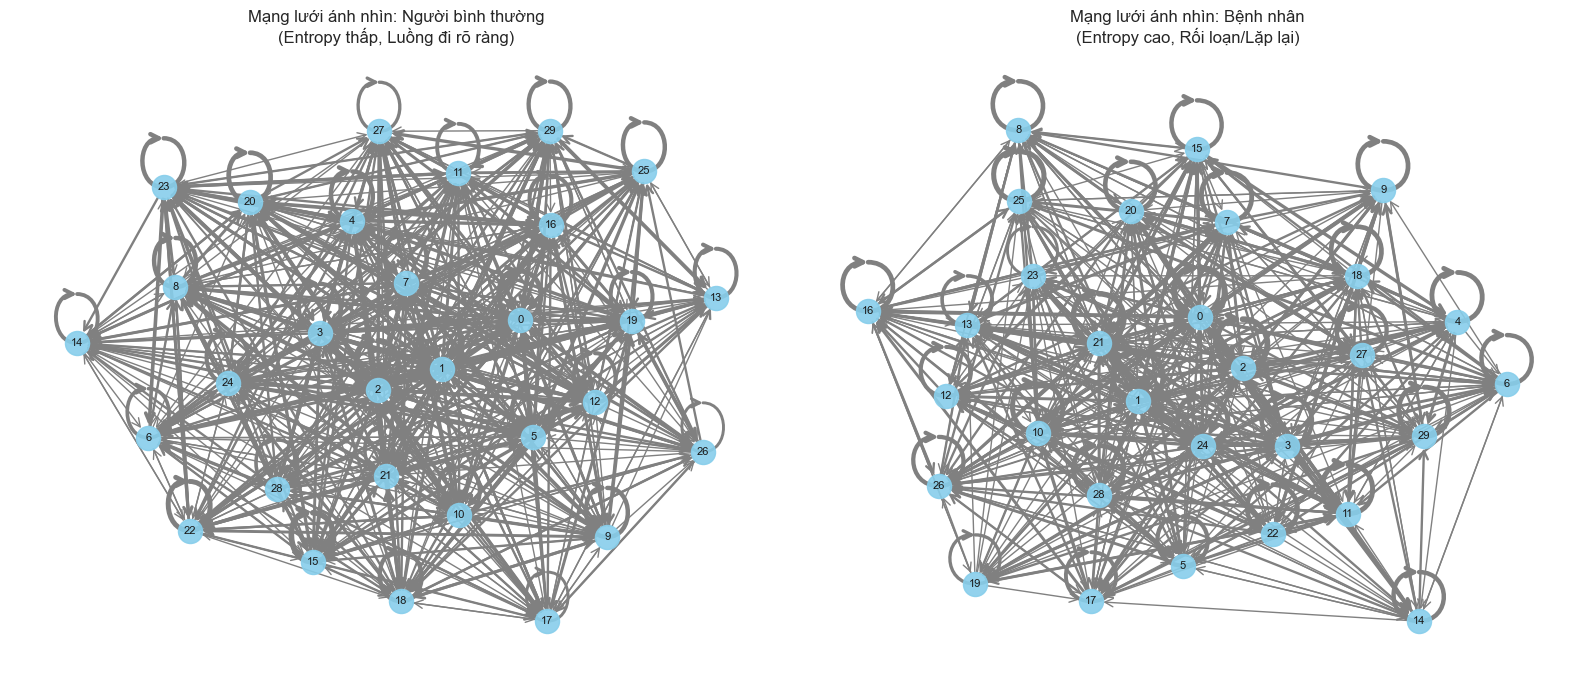

In [45]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# vẽ ra sơ đồ nhìn của hai người 1 bệnh và 1 người bình thường dựa trên các điểm nhìn đã có qua 100 ảnh
# Tìm index của người thường và bệnh (dựa trên nhãn y)
idx_normal = np.where(y == 0)[0][0] # Người thường đầu tiên
idx_patient = np.where(y == 1)[0][0] # Người bệnh đầu tiên
def plot_gaze_network(doc_string, title, ax):
    nodes = [int(x) for x in doc_string.split()]
    G = nx.DiGraph()
    edge_weights = {}
    for i in range(len(nodes)-1):
        edge = (nodes[i], nodes[i+1])
        if edge in edge_weights:
            edge_weights[edge] += 1
        else:
            edge_weights[edge] = 1
            
    for edge, weight in edge_weights.items():
        G.add_edge(edge[0], edge[1], weight=weight)
        
    pos = nx.spring_layout(G, k=0.5, seed=42) # Layout lò xo

    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=300, node_color='skyblue', alpha=0.9)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
    
    weights = [G[u][v]['weight'] for u,v in G.edges()]
    widths = [1 + np.log(w) for w in weights]
    
    nx.draw_networkx_edges(G, pos, ax=ax, width=widths, edge_color='gray', arrowstyle='->', arrowsize=15)
    
    ax.set_title(title)
    ax.axis('off')


doc_normal = docs[idx_normal]
doc_patient = docs[idx_patient]
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plot_gaze_network(doc_normal, f"Mạng lưới ánh nhìn: Người bình thường\n(Entropy thấp, Luồng đi rõ ràng)", axes[0])
plot_gaze_network(doc_patient, f"Mạng lưới ánh nhìn: Bệnh nhân\n(Entropy cao, Rối loạn/Lặp lại)", axes[1])

plt.tight_layout()
plt.show()

In [46]:
import pandas as pd
import numpy as np
print("lưu dữ liệu ra file để train")
pids = list(patient_docs.keys())
try:
    phys_names = ['PathLen', 'HullArea', 'Entropy', 'Duration']
    graph_names = ['Density', 'Clustering', 'NumComponents', 'Assortativity']
    ngram_names = vectorizer.get_feature_names_out()
    all_names = phys_names + graph_names + list(ngram_names)
except NameError:
    print("error!")
if X_full.shape[1] != len(all_names):
    print(f"Cảnh báo: Kích thước không khớp! X_full có {X_full.shape[1]} cột, nhưng tên cột có {len(all_names)} tên.")
    print("Đang tự động cắt hoặc điều chỉnh...")
else:
    df_export = pd.DataFrame(X_full, columns=all_names)
    # 4. Thêm cột định danh (Numeric ID) và Nhãn (Label)
    df_export.insert(0, 'numeric_id', pids) # Chèn ID vào cột đầu tiên
    df_export['label'] = y
    # 5. Lưu ra file CSV
    filename = 'eye_tracking_features_k30_graph.csv'
    df_export.to_csv(filename, index=False)
    print(f"Đã lưu thành công file: {filename}")
    print(f"Kích thước dữ liệu: {df_export.shape}")
    print(df_export.head(10))

lưu dữ liệu ra file để train
Đã lưu thành công file: eye_tracking_features_k30_graph.csv
Kích thước dữ liệu: (160, 910)
   numeric_id      PathLen       HullArea   Entropy    Duration   Density  \
0           0  2861.105924  190807.712300  2.144868  286.170447  0.168423   
1           1  2023.887205  122535.789500  2.022084  400.321916  0.193500   
2           2  2703.052116  130401.048250  2.041287  278.481984  0.203237   
3           3  2640.227937  197510.778650  2.183084  265.981839  0.163372   
4           4  2270.180823  134530.891474  1.992435  423.162296  0.195987   
5           5  2623.633085  139409.310650  2.059908  275.157152  0.178669   
6           6  2706.267177  164702.408300  2.051438  353.628311  0.179001   
7           7  2775.153003  180376.505950  2.123029  264.103404  0.186683   
8           8  1844.677066   89145.760400  1.940772  334.514896  0.224663   
9           9  2385.164239  140559.790950  2.073404  340.025101  0.197685   

   Clustering  NumComponents  As

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv('eye_tracking_features_k30_graph.csv')
X = df.drop(columns=['label', 'numeric_id'])
y = df['label']
feature_names = X.columns
df['Group'] = df['label'].apply(lambda x: 'Patient (Bệnh)' if x == 1 else 'Normal (Thường)')
sns.set(style="whitegrid", palette="muted")
print("Đã tải dữ liệu và thiết lập xong!")
print(f"Số lượng mẫu: {len(df)}")

Đã tải dữ liệu và thiết lập xong!
Số lượng mẫu: 160


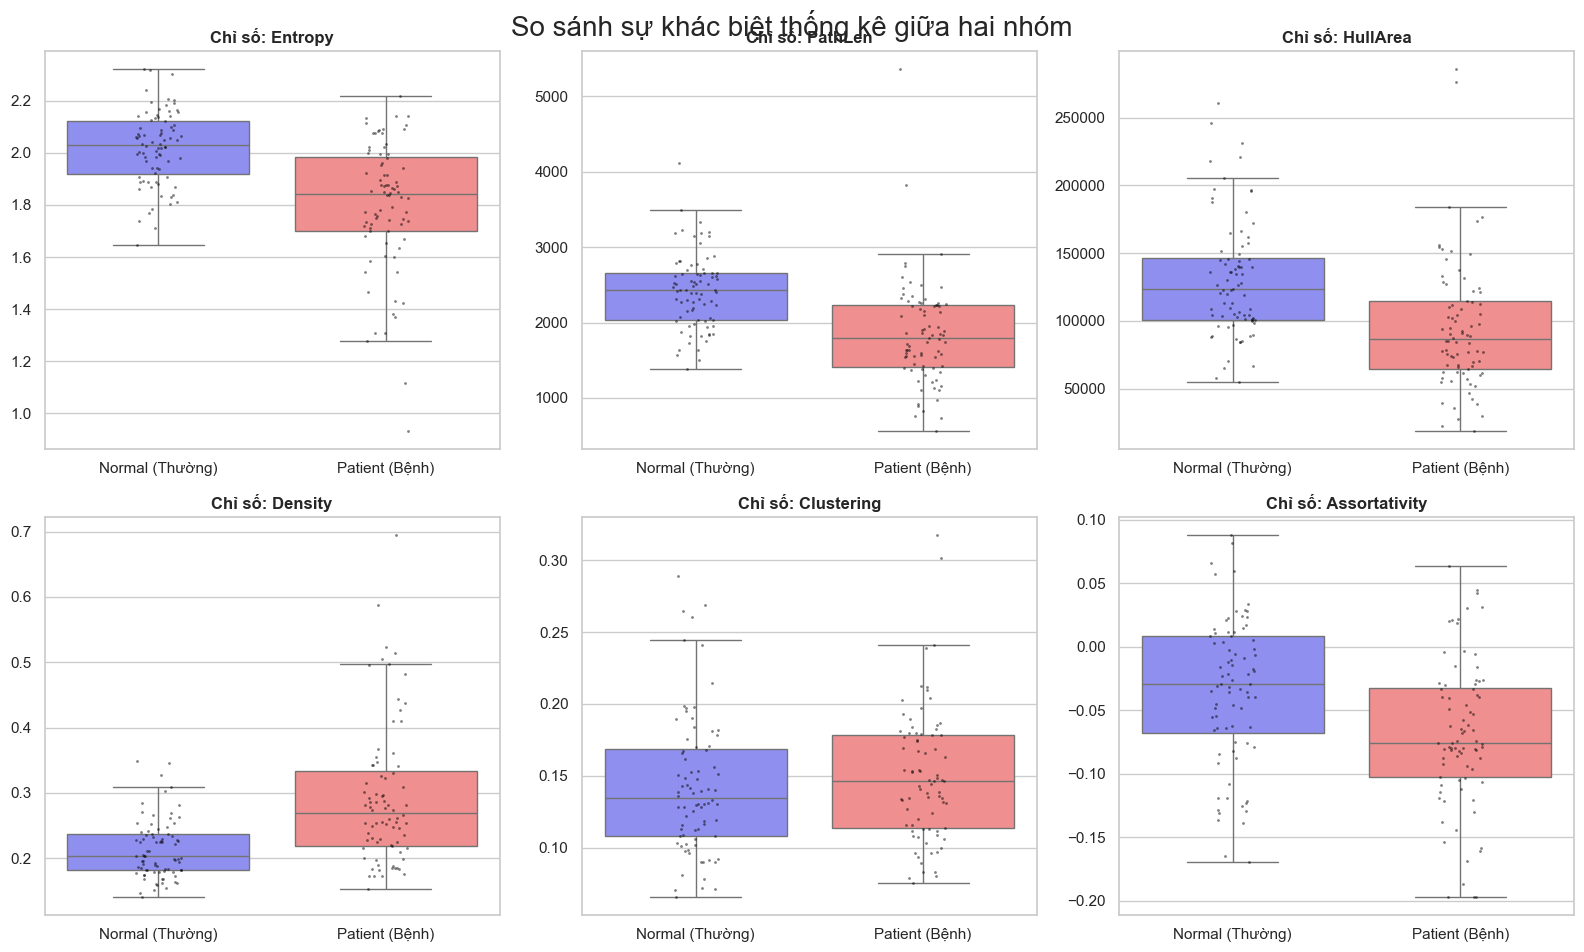

In [48]:
# --- BIỂU ĐỒ 1: SO SÁNH PHÂN PHỐI (BOX PLOT) ---
key_features = ['Entropy', 'PathLen', 'HullArea', 'Density', 'Clustering', 'Assortativity']
plt.figure(figsize=(16, 10))
plt.suptitle('So sánh sự khác biệt thống kê giữa hai nhóm', fontsize=20, y=0.95)

for i, col in enumerate(key_features):
    if col in df.columns:
        plt.subplot(2, 3, i+1)
        # Vẽ Boxplot
        sns.boxplot(x='Group', y=col, data=df, showfliers=False, 
                    palette={'Patient (Bệnh)': '#ff7f7f', 'Normal (Thường)': '#7f7fff'})
        sns.stripplot(x='Group', y=col, data=df, color='black', size=2, alpha=0.5)
        
        plt.title(f'Chỉ số: {col}', fontweight='bold')
        plt.xlabel('')
        plt.ylabel('')

plt.tight_layout()
plt.show()

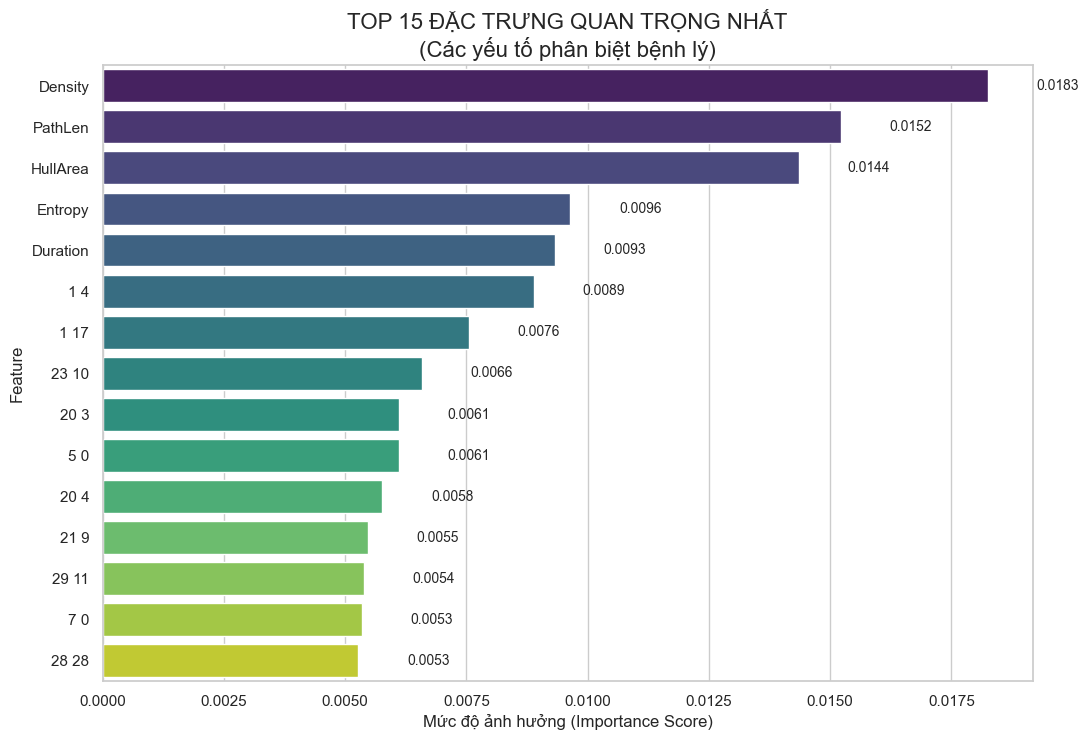

In [49]:
# --- BIỂU ĐỒ 2: FEATURE IMPORTANCE (TOP 15) ---

rf_viz = RandomForestClassifier(n_estimators=100, random_state=42)
rf_viz.fit(X, y)
importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_viz.feature_importances_
}).sort_values(by='Importance', ascending=False).head(15) # Lấy Top 15

plt.figure(figsize=(12, 8))
barplot = sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')
for i, v in enumerate(importances['Importance']):
    barplot.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10)
plt.title('TOP 15 ĐẶC TRƯNG QUAN TRỌNG NHẤT\n(Các yếu tố phân biệt bệnh lý)', fontsize=16)
plt.xlabel('Mức độ ảnh hưởng (Importance Score)')
plt.show()

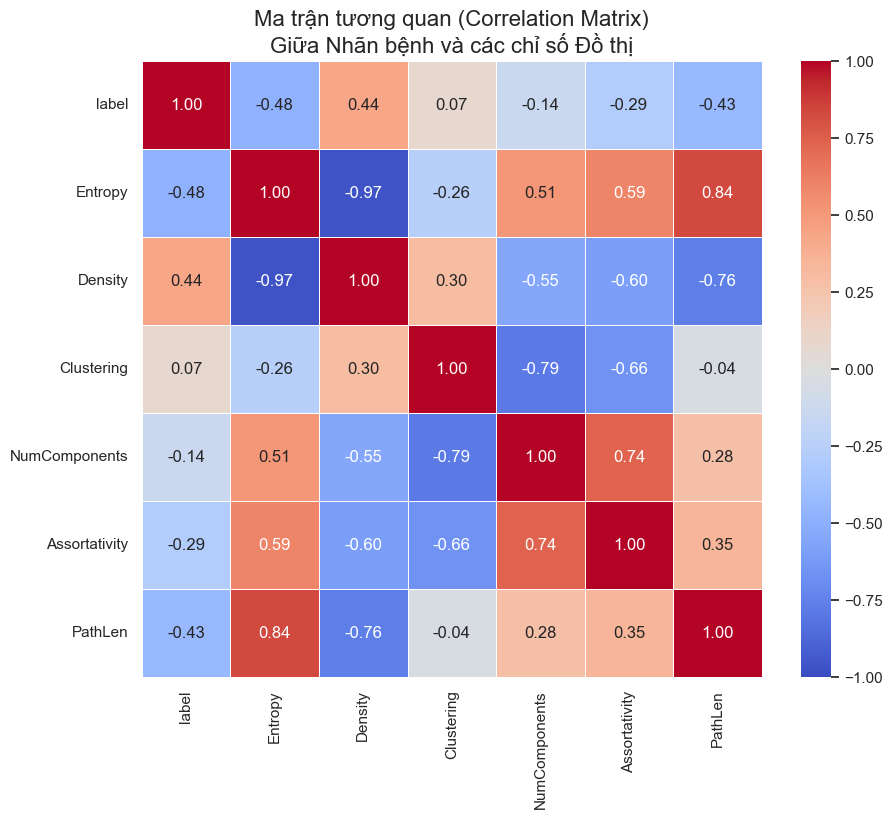

In [50]:
# --- BIỂU ĐỒ 3: MA TRẬN TƯƠNG QUAN (GRAPH FEATURES) ---
graph_cols = ['label', 'Entropy', 'Density', 'Clustering', 'NumComponents', 'Assortativity', 'PathLen']
corr_matrix = df[graph_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title('Ma trận tương quan (Correlation Matrix)\nGiữa Nhãn bệnh và các chỉ số Đồ thị', fontsize=16)
plt.show()

Đang chạy t-SNE và tính toán mật độ...


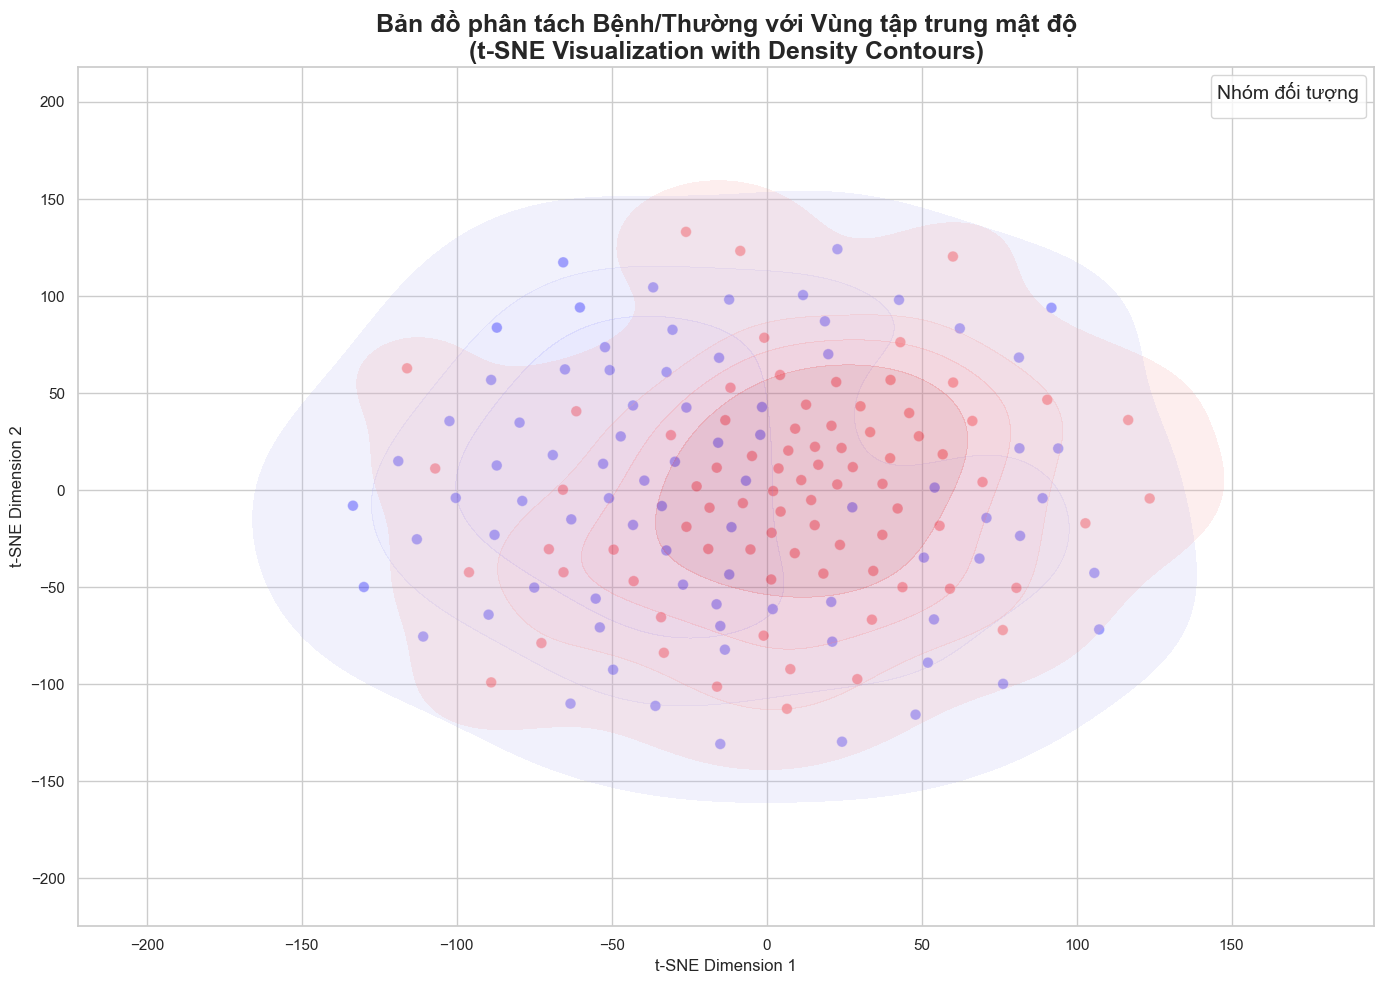

In [51]:
# --- CELL 4 MỚI (PHƯƠNG ÁN 1): t-SNE VỚI ĐƯỜNG ĐỒNG MỨC ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# (Đảm bảo bạn đã chạy Cell 1 để có df, X, y)

print("Đang chạy t-SNE và tính toán mật độ...")

# 1. Chuẩn hóa và chạy t-SNE
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate=200)
X_tsne = tsne.fit_transform(X_scaled)

# 2. Tạo DataFrame tạm để vẽ
df_tsne = pd.DataFrame(X_tsne, columns=['Dim1', 'Dim2'])
df_tsne['Group'] = df['Group']

# 3. Vẽ biểu đồ
plt.figure(figsize=(14, 10))

# Lớp nền: Vẽ các điểm chấm (nhạt hơn một chút để làm nền)
sns.scatterplot(
    x='Dim1', y='Dim2',
    hue='Group',
    palette={'Patient (Bệnh)': 'red', 'Normal (Thường)': 'blue'},
    data=df_tsne,
    s=60, alpha=0.4, legend=False # Ẩn legend của scatter để dùng legend của kde
)

# Lớp chính: Vẽ đường đồng mức mật độ (KDE contours)
# thresh=0.05: Bỏ qua 5% vùng mật độ thấp nhất cho đỡ rối
# levels=5: Vẽ 5 vòng tròn đồng mức
sns.kdeplot(
    x='Dim1', y='Dim2',
    hue='Group',
    palette={'Patient (Bệnh)': 'red', 'Normal (Thường)': 'blue'},
    data=df_tsne,
    fill=True, alpha=0.2, # Tô màu nhạt bên trong vòng tròn
    linewidths=2, # Đường viền đậm
    thresh=0.05, levels=5
)

plt.title('Bản đồ phân tách Bệnh/Thường với Vùng tập trung mật độ\n(t-SNE Visualization with Density Contours)', fontsize=18, fontweight='bold')
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.legend(title='Nhóm đối tượng', fontsize=12, title_fontsize=14, loc='best')

plt.tight_layout()
plt.show()

Đang chạy t-SNE và tạo bản đồ nhiệt...


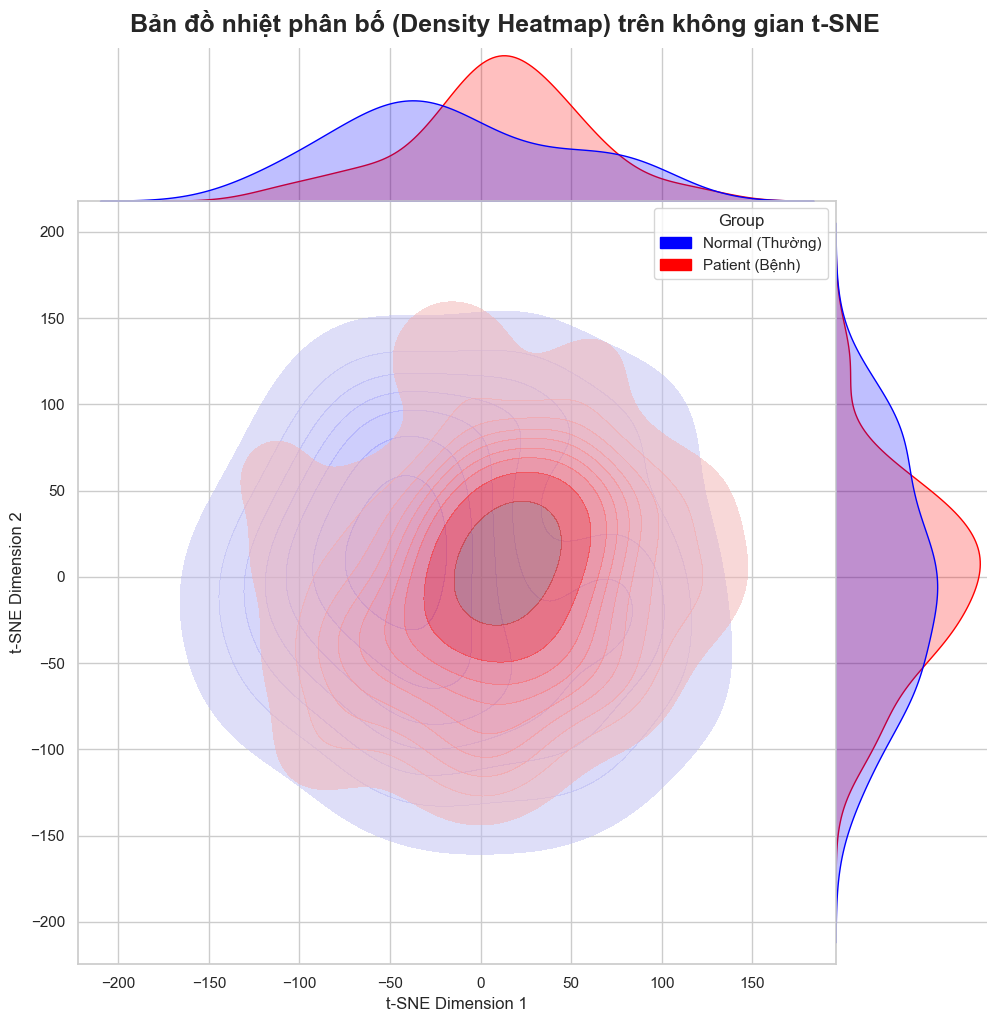

In [52]:
# --- CELL 4 MỚI (PHƯƠNG ÁN 2): BIỂU ĐỒ MẬT ĐỘ NHIỆT (HEXBIN) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

print("Đang chạy t-SNE và tạo bản đồ nhiệt...")

# 1. Chuẩn hóa và chạy t-SNE
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate=200)
X_tsne = tsne.fit_transform(X_scaled)

# 2. Tạo DataFrame tạm
df_tsne = pd.DataFrame(X_tsne, columns=['Dim1', 'Dim2'])
df_tsne['Group'] = df['Group']

# 3. Vẽ Jointplot dạng Hexbin (cho từng nhóm)
# Để vẽ 2 nhóm riêng biệt trên cùng 1 jointplot hơi phức tạp,
# Ta sẽ vẽ KDE Jointplot (dạng đường cong mượt) sẽ đẹp hơn cho việc so sánh 2 nhóm.

g = sns.jointplot(
    x='Dim1', y='Dim2',
    data=df_tsne,
    hue='Group',
    kind='kde', # Loại biểu đồ là KDE (mật độ mượt)
    palette={'Patient (Bệnh)': 'red', 'Normal (Thường)': 'blue'},
    fill=True, alpha=0.5, # Tô màu bán trong suốt
    height=10, space=0
)

g.fig.suptitle('Bản đồ nhiệt phân bố (Density Heatmap) trên không gian t-SNE', fontsize=18, fontweight='bold', y=1.02)
g.set_axis_labels('t-SNE Dimension 1', 't-SNE Dimension 2', fontsize=12)

plt.show()

1. Đang chạy t-SNE...
2. Đang tự động dò tìm tham số eps tối ưu...

=> TÌM THẤY THAM SỐ TỐT NHẤT!
   Eps: 14.5
   ARI Score: 0.0862


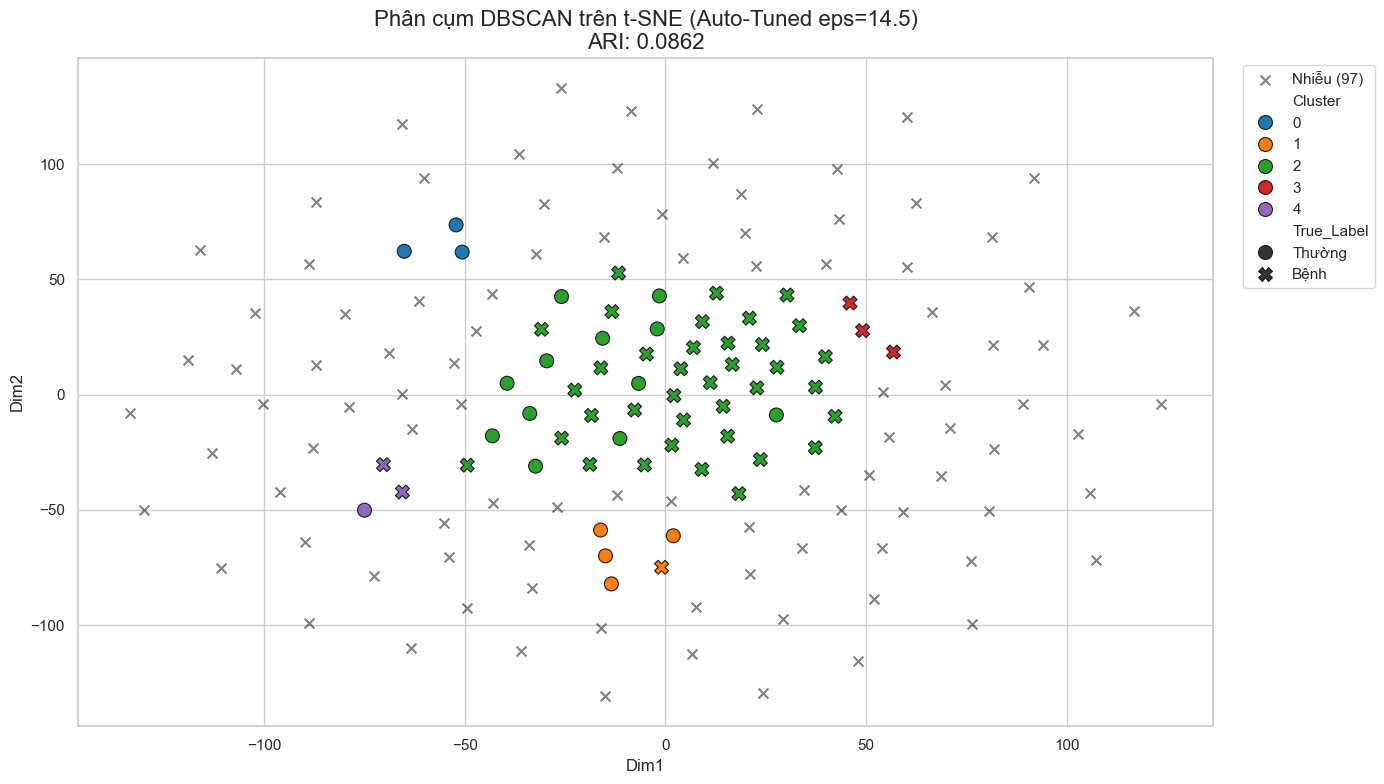

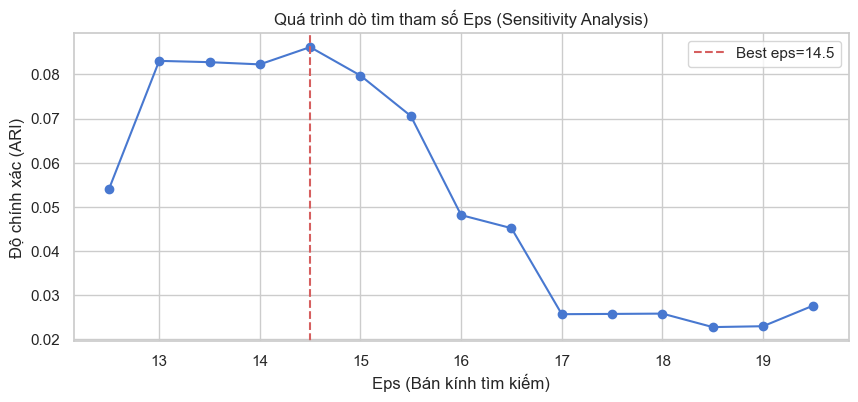

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score

# 1. Chuẩn bị dữ liệu
df = pd.read_csv('eye_tracking_features_k30_graph.csv')
X = df.drop(columns=['label', 'numeric_id'])
y_true = df['label']

# 2. Chạy t-SNE (Giảm xuống 2 chiều)
print("1. Đang chạy t-SNE...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate=200)
X_embedded = tsne.fit_transform(X_scaled)

# 3. AUTO-TUNE: Vòng lặp tìm eps tốt nhất
print("2. Đang tự động dò tìm tham số eps tối ưu...")

best_score = -1
best_eps = 0
best_labels = None
results = []

# Thử eps từ 0.5 đến 20, bước nhảy 0.5
for eps in np.arange(0.5, 25.0, 0.5):
    # min_samples thấp thôi để dễ bắt cụm
    db = DBSCAN(eps=eps, min_samples=3).fit(X_embedded)
    labels = db.labels_
    
    # Đếm số cụm (không tính nhiễu -1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    # Chỉ xét nếu tìm được ít nhất 2 cụm và không phải toàn bộ là nhiễu
    if n_clusters >= 2 and n_noise < len(labels):
        score = adjusted_rand_score(y_true, labels)
        results.append((eps, score, n_clusters, n_noise))
        
        if score > best_score:
            best_score = score
            best_eps = eps
            best_labels = labels

# 4. Báo cáo kết quả dò tìm
if best_labels is None:
    print("Vẫn không tìm thấy cụm nào khả thi. Dữ liệu t-SNE quá phân tán.")
else:
    print(f"\n=> TÌM THẤY THAM SỐ TỐT NHẤT!")
    print(f"   Eps: {best_eps}")
    print(f"   ARI Score: {best_score:.4f}")
    
    # Vẽ biểu đồ
    plt.figure(figsize=(14, 8))
    
    # Tạo dataframe vẽ
    plot_df = pd.DataFrame(X_embedded, columns=['Dim1', 'Dim2'])
    plot_df['Cluster'] = best_labels
    plot_df['True_Label'] = y_true.apply(lambda x: 'Bệnh' if x==1 else 'Thường')
    
    # Vẽ Nhiễu
    noise = plot_df[plot_df['Cluster'] == -1]
    if len(noise) > 0:
        plt.scatter(noise['Dim1'], noise['Dim2'], c='black', marker='x', s=50, label=f'Nhiễu ({len(noise)})', alpha=0.5)
    
    # Vẽ Cụm
    clusters = plot_df[plot_df['Cluster'] != -1]
    sns.scatterplot(
        data=clusters, x='Dim1', y='Dim2', 
        hue='Cluster', style='True_Label',
        palette='tab10', s=100, edgecolor='k'
    )
    
    

    plt.title(f'Phân cụm DBSCAN trên t-SNE (Auto-Tuned eps={best_eps})\nARI: {best_score:.4f}', fontsize=16)
    plt.legend(bbox_to_anchor=(1.02, 1), loc=2)
    plt.tight_layout()
    plt.show()
    
    # Vẽ biểu đồ biến thiên ARI theo Eps để đưa vào báo cáo
    eps_list = [r[0] for r in results]
    ari_list = [r[1] for r in results]
    
    plt.figure(figsize=(10, 4))
    plt.plot(eps_list, ari_list, marker='o')
    plt.axvline(x=best_eps, color='r', linestyle='--', label=f'Best eps={best_eps}')
    plt.title('Quá trình dò tìm tham số Eps (Sensitivity Analysis)')
    plt.xlabel('Eps (Bán kính tìm kiếm)')
    plt.ylabel('Độ chính xác (ARI)')
    plt.legend()
    plt.grid(True)
    plt.show()